# 01 · Exploratory data analysis

Phase 1 of `notes/plan.md`. This notebook answers the three milestone questions (inclusion/exclusion, preprocessing, and splits) and writes `splits/splits.csv`, which every later notebook uses. Run `00_setup_and_download.ipynb` first.

**Local setup (once):**
```bash
conda env create -f environment.yml && conda activate cellcount
python -m ipykernel install --user --name cellcount --display-name "Python (cellcount)"
nbstripout --install   # strip notebook outputs on commit
cp .env.example .env   # then fill in ROBOFLOW_EXPORT_URL
```
Then select the **Python (cellcount)** kernel.

**Colab:** open this notebook from GitHub (File > Open notebook > GitHub), add the secrets, and Run all.

In [1]:
# --- Bootstrap (identical in every notebook). Does nothing when run locally. ---
# On Colab: mounts Google Drive (data/ and outputs/ live there), clones or updates the repo,
# and installs the `cellcount` utils. Secrets: add ROBOFLOW_EXPORT_URL (and GH_TOKEN if the
# repo is private) under the key icon in the left sidebar, with notebook access enabled.
import os, subprocess, sys

REPO_URL = "https://github.com/singhp99/cell-image-counting.git"
BRANCH = "main"  # set to a feature branch to try unmerged work

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive, userdata

    drive.mount("/content/drive")
    repo = "/content/cell-image-counting"
    try:
        url = REPO_URL.replace("https://", f"https://{userdata.get('GH_TOKEN')}@")
    except Exception:
        url = REPO_URL
    cmd = ["git", "-C", repo, "pull", "-q"] if os.path.exists(repo) else ["git", "clone", "-q", "-b", BRANCH, url, repo]
    if subprocess.run(cmd).returncode != 0:
        raise RuntimeError("git clone/pull failed: check BRANCH and the GH_TOKEN secret")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", repo], check=True)
    sys.path.insert(0, f"{repo}/src")  # import without restarting the runtime
    os.chdir(repo)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from cellcount import eda, splits, viz
from cellcount.config import get_paths
from cellcount.data import RAW_DIRNAME, load_coco

sns.set_theme(style="whitegrid", context="notebook")
paths = get_paths()
images, boxes = load_coco(paths.data / RAW_DIRNAME)

# Per-image class counts (Live / Dead)
per_class = boxes.pivot_table(index="uid", columns="category", values="x", aggfunc="size", fill_value=0)
images = images.join(per_class, on="uid").fillna({c: 0 for c in per_class.columns})
images["dead_frac"] = images.get("Dead", 0) / images["count"].where(images["count"] > 0)
images.head()

/Users/dingshandeng/anaconda3/envs/cellcount/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,uid,split,image_id,file_name,path,width,height,original_name,source,frame,count,Dead,Live,dead_frac
0,train/0,train,0,2022_12_7_1_A-creport_181_jpg.rf.HnH6PEXE8g1Pz...,/Users/dingshandeng/project/2-project_AInML/ce...,640,640,2022_12_7_1_A-creport_181,2022_12_7_1_A,181,53,1,52,0.018868
1,train/1,train,1,2022_12_7_2_B-creport_572_jpg.rf.37WTuSMFSeH1g...,/Users/dingshandeng/project/2-project_AInML/ce...,640,640,2022_12_7_2_B-creport_572,2022_12_7_2_B,572,35,3,32,0.085714
2,train/2,train,2,2022_12_7_1_B-creport_254_jpg.rf.33wvrcXApNP9Y...,/Users/dingshandeng/project/2-project_AInML/ce...,640,640,2022_12_7_1_B-creport_254,2022_12_7_1_B,254,70,3,67,0.042857
3,train/3,train,3,2022_12_7_1_B-creport_333_jpg.rf.HdMsIzrsoZyUo...,/Users/dingshandeng/project/2-project_AInML/ce...,640,640,2022_12_7_1_B-creport_333,2022_12_7_1_B,333,81,2,79,0.024691
4,train/4,train,4,2022_12_7_1_A-creport_146_jpg.rf.GjExIuUcmwCRB...,/Users/dingshandeng/project/2-project_AInML/ce...,640,640,2022_12_7_1_A-creport_146,2022_12_7_1_A,146,58,1,57,0.017241


## 1. Overview and samples

In [3]:
summary = images.groupby("split").agg(images=("uid", "size"), cells=("count", "sum"),
                                      live=("Live", "sum"), dead=("Dead", "sum"))
summary.loc["total"] = summary.sum()
summary

,images,cells,live,dead
split,,,,
test,50,2761,2653,108
train,350,18582,17878,704
valid,100,5372,5160,212
total,500,26715,25691,1024


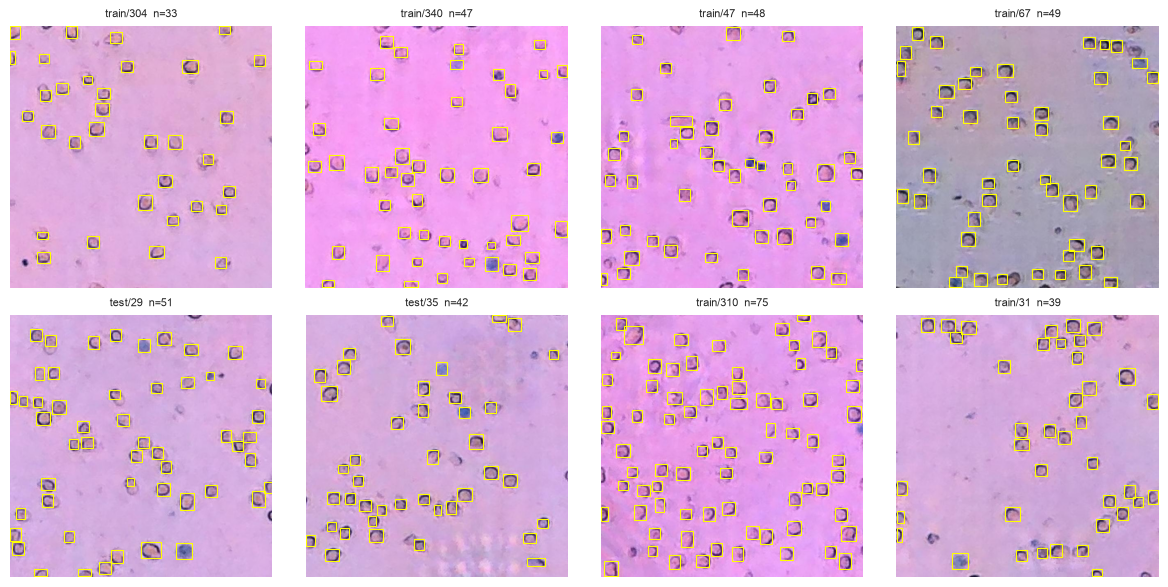

In [4]:
viz.show_samples(images, boxes, n=8, seed=1);

## 2. Image size and aspect ratio

In [5]:
images[["width", "height"]].value_counts().rename("images").to_frame()

,,images
width,height,
640,640,500


## 3. Cell-count distribution

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,50.0,55.2,13.9,29.0,43.2,57.0,64.8,88.0
train,350.0,53.1,14.9,23.0,41.0,52.0,66.0,91.0
valid,100.0,53.7,13.1,26.0,42.8,56.0,64.2,84.0


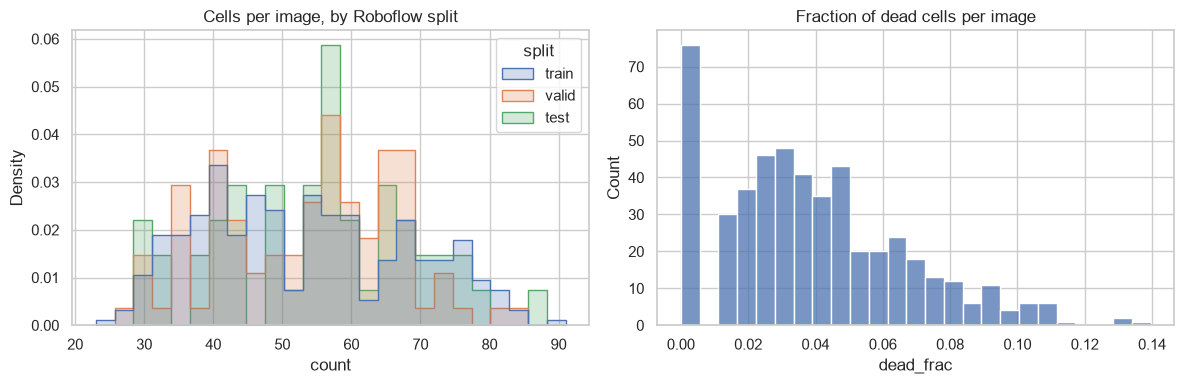

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(images, x="count", hue="split", element="step", stat="density", common_norm=False, bins=25, ax=axes[0])
axes[0].set_title("Cells per image, by Roboflow split")
sns.histplot(images, x="dead_frac", bins=25, ax=axes[1])
axes[1].set_title("Fraction of dead cells per image")
plt.tight_layout()
images.groupby("split")["count"].describe().round(1)

In [7]:
images["count_bin"] = eda.count_bins(images["count"])
images["count_bin"].value_counts().sort_index().rename("images").to_frame()

,images
count_bin,
"(-inf, 42.0]",139
"(42.0, 54.0]",124
"(54.0, 65.0]",115
"(65.0, inf]",122


## 3b. Counts by acquisition source

Roboflow file names keep the original name, e.g. `2022_12_7_1_A-creport_181`. That gives a session and well (`source`) and a frame number. If density depends on the source, a model can learn to infer the count from image style alone.

split,test,train,valid,All
source,,,,
2022_12_7_1_A,11,68,21,100
2022_12_7_1_B,8,73,19,100
2022_12_7_2_A,5,73,22,100
2022_12_7_2_B,12,74,14,100
2022_12_7_3_A,14,62,24,100
All,50,350,100,500


count        dead_frac       
                mean    std      mean    std
source                                      
2022_12_7_1_A  53.12  7.948     0.036  0.027
2022_12_7_1_B  71.10  7.779     0.039  0.025
2022_12_7_2_A  37.49  5.834     0.038  0.032
2022_12_7_2_B  43.26  8.321     0.043  0.030
2022_12_7_3_A  62.18  8.521     0.039  0.026

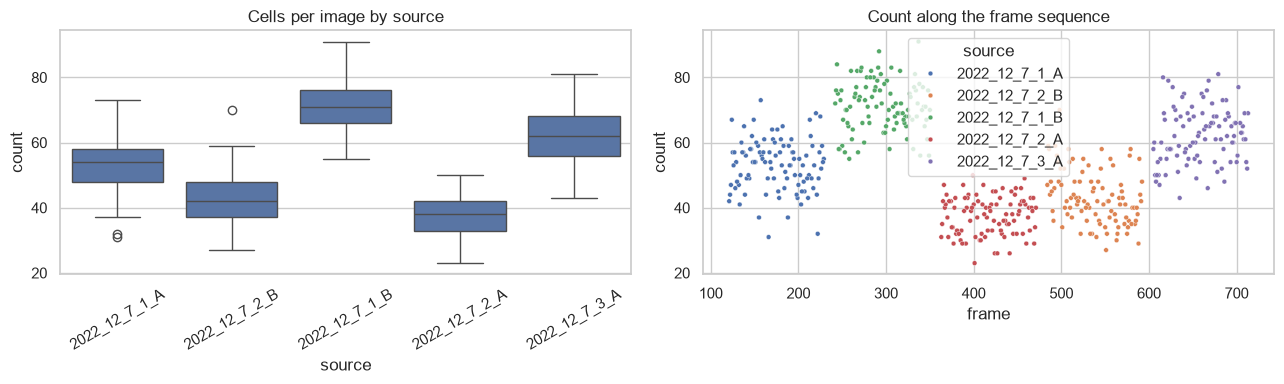

In [8]:
display(pd.crosstab(images["source"], images["split"], margins=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=images, x="source", y="count", ax=axes[0]); axes[0].set_title("Cells per image by source")
axes[0].tick_params(axis="x", rotation=30)
sns.scatterplot(data=images, x="frame", y="count", hue="source", s=12, ax=axes[1]); axes[1].set_title("Count along the frame sequence")
plt.tight_layout()
images.groupby("source")[["count", "dead_frac"]].agg(["mean", "std"]).round(3)

## 4. Cell (box) size

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Dead,1024.0,28.3,6.6,12.5,23.5,27.7,32.0,64.0
Live,25691.0,28.4,4.3,11.7,25.4,28.6,31.0,60.7


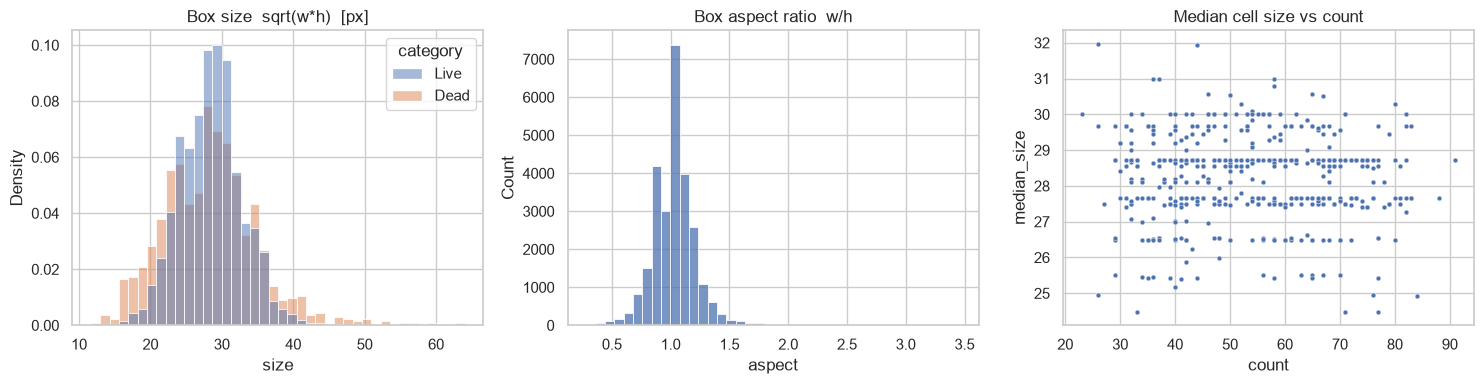

In [9]:
boxes["size"] = np.sqrt(boxes["area"])
boxes["aspect"] = boxes["w"] / boxes["h"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(boxes, x="size", hue="category", stat="density", common_norm=False, bins=40, ax=axes[0])
axes[0].set_title("Box size  sqrt(w*h)  [px]")
sns.histplot(boxes, x="aspect", bins=40, ax=axes[1])
axes[1].set_title("Box aspect ratio  w/h")
per_img_size = boxes.groupby("uid")["size"].median().rename("median_size")
sns.scatterplot(data=images.join(per_img_size, on="uid"), x="count", y="median_size", s=12, ax=axes[2])
axes[2].set_title("Median cell size vs count")
plt.tight_layout()
boxes.groupby("category")["size"].describe().round(1)

## 5. Overlap between cells

,max_iou,frac_overlapping
count,500.000,500.000
mean,0.016,0.001
std,0.028,0.006
min,0.000,0.000
25%,0.000,0.000
50%,0.006,0.000
75%,0.021,0.000
max,0.215,0.054


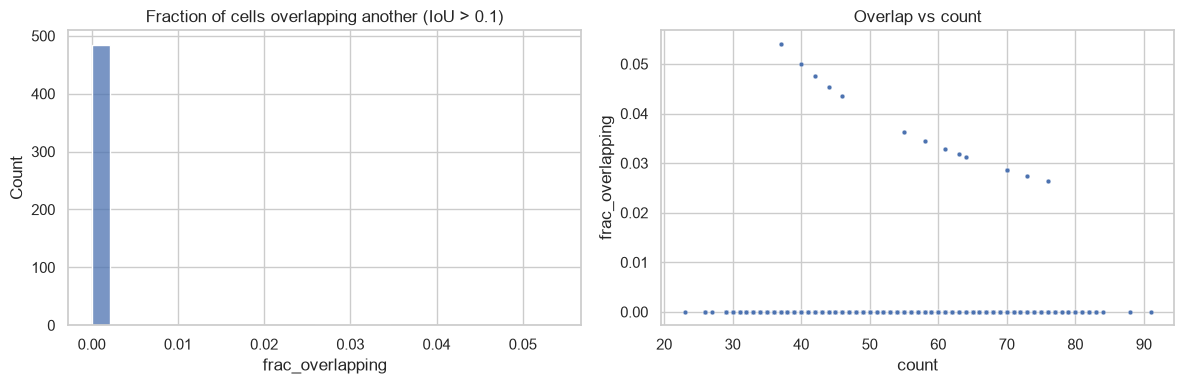

In [10]:
ov = eda.overlap_stats(boxes)
images = images.merge(ov, on="uid", how="left").fillna({"max_iou": 0, "frac_overlapping": 0})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(images, x="frac_overlapping", bins=25, ax=axes[0])
axes[0].set_title("Fraction of cells overlapping another (IoU > 0.1)")
sns.scatterplot(data=images, x="count", y="frac_overlapping", s=12, ax=axes[1])
axes[1].set_title("Overlap vs count")
plt.tight_layout()
images[["max_iou", "frac_overlapping"]].describe().round(3)

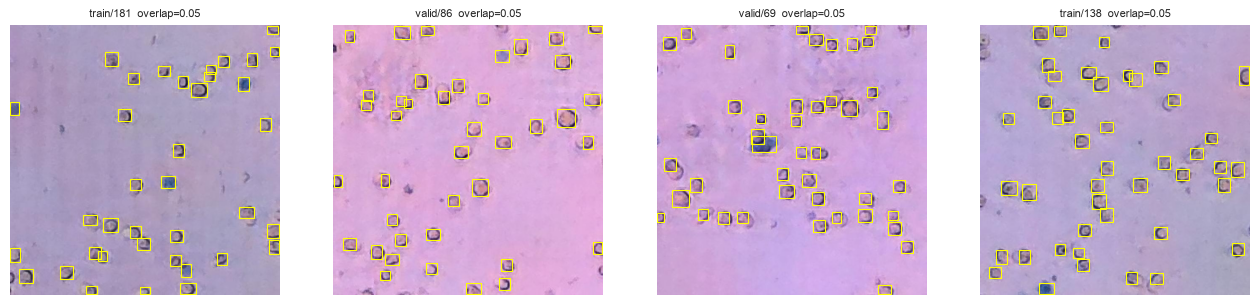

In [11]:
crowded = images.nlargest(4, "frac_overlapping")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, crowded.iterrows()):
    viz.show_image(row, boxes, ax=ax, title=f"{row['uid']}  overlap={row['frac_overlapping']:.2f}")

## 6. Colour and background

Mean RGB per image, clustered with k-means. Check the elbow plot before trusting `K`.

image stats:   0%|          | 0/500 [00:00<?, ?it/s]

image stats:   2%|▏         | 8/500 [00:00<00:06, 76.47it/s]

image stats:   3%|▎         | 17/500 [00:00<00:05, 82.24it/s]

image stats:   5%|▌         | 26/500 [00:00<00:05, 84.04it/s]

image stats:   7%|▋         | 35/500 [00:00<00:05, 84.42it/s]

...

image stats:  93%|█████████▎| 467/500 [00:05<00:00, 85.43it/s]

image stats:  95%|█████████▌| 476/500 [00:05<00:00, 85.53it/s]

image stats:  97%|█████████▋| 485/500 [00:05<00:00, 85.53it/s]

image stats:  99%|█████████▉| 494/500 [00:05<00:00, 84.49it/s]

image stats: 100%|██████████| 500/500 [00:05<00:00, 84.95it/s]

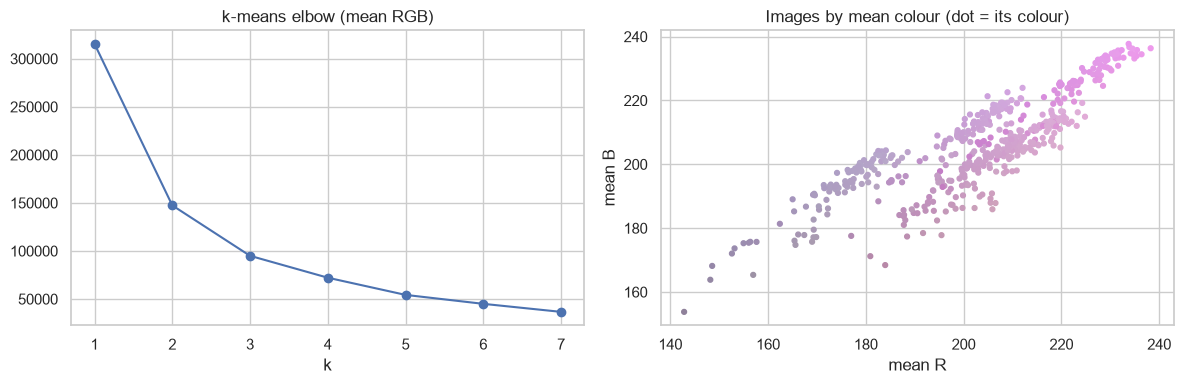

In [12]:
stats = eda.image_stats(images)
images = images.merge(stats, on="uid")

from sklearn.cluster import KMeans
X = images[["mean_r", "mean_g", "mean_b"]].to_numpy()
inertia = [KMeans(k, n_init=10, random_state=0).fit(X).inertia_ for k in range(1, 8)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 8), inertia, marker="o"); axes[0].set_title("k-means elbow (mean RGB)"); axes[0].set_xlabel("k")
axes[1].scatter(images["mean_r"], images["mean_b"], c=images[["mean_r", "mean_g", "mean_b"]].to_numpy() / 255, s=12)
axes[1].set_xlabel("mean R"); axes[1].set_ylabel("mean B"); axes[1].set_title("Images by mean colour (dot = its colour)")
plt.tight_layout()

,mean_r,mean_g,mean_b,brightness,count,images
bg_group,,,,,,
0,180.4,153.9,190.6,166.0,53.5,156
1,207.8,161.2,207.4,180.4,50.9,259
2,226.3,151.0,228.2,182.3,61.0,85


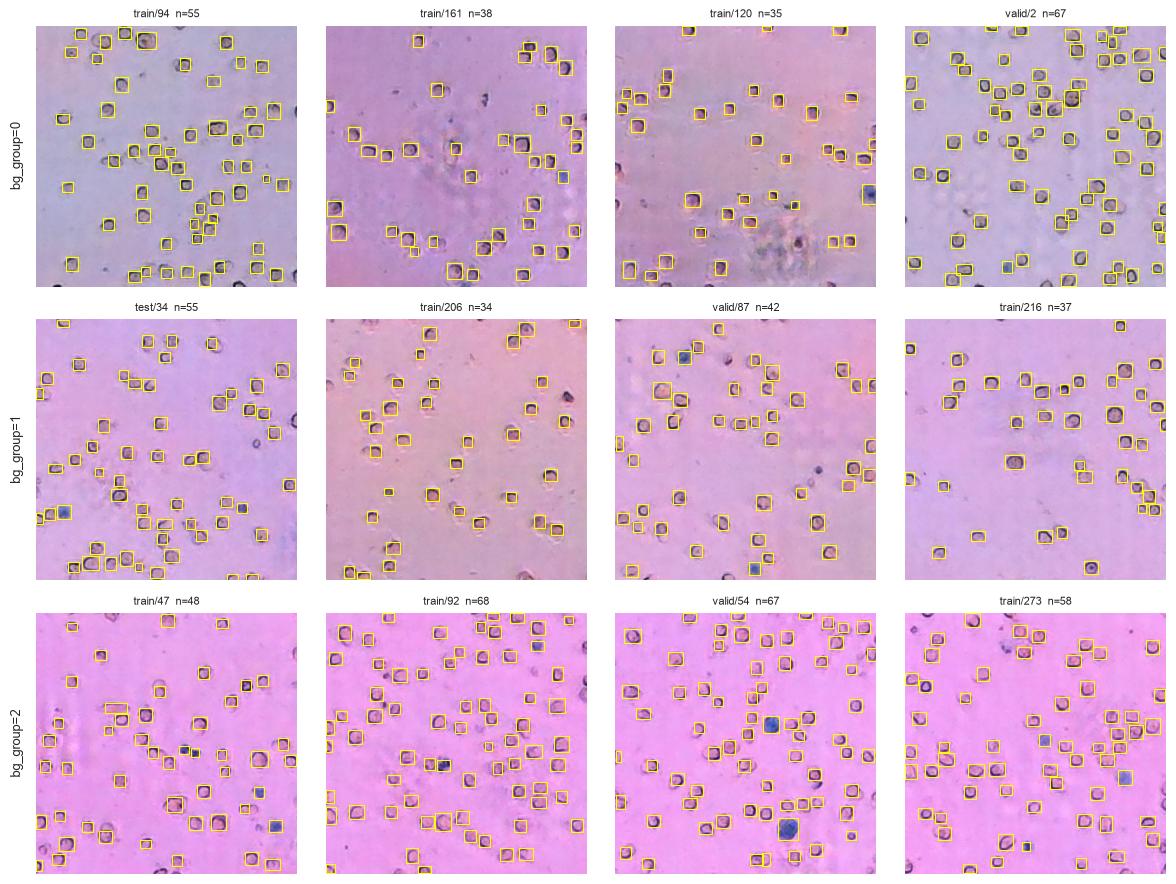

In [13]:
K = 3  # adjust after reading the elbow plot
images["bg_group"] = images["uid"].map(eda.background_groups(stats, k=K))
display(images.groupby("bg_group")[["mean_r", "mean_g", "mean_b", "brightness", "count"]].mean().round(1)
        .join(images["bg_group"].value_counts().rename("images")))
viz.show_samples(images, boxes, by="bg_group", ncols=4);

In [14]:
display(pd.crosstab(images["bg_group"], images["split"], normalize="columns").round(2))
pd.crosstab(images["source"], images["bg_group"])

split,test,train,valid
bg_group,,,
0,0.30,0.31,0.31
1,0.46,0.53,0.49
2,0.24,0.15,0.20


bg_group,0,1,2
source,,,
2022_12_7_1_A,100,0,0
2022_12_7_1_B,25,75,0
2022_12_7_2_A,11,88,1
2022_12_7_2_B,18,82,0
2022_12_7_3_A,2,14,84


## 7. Blur and image quality

`blur` is the variance of the Laplacian; lower values mean a blurrier image.

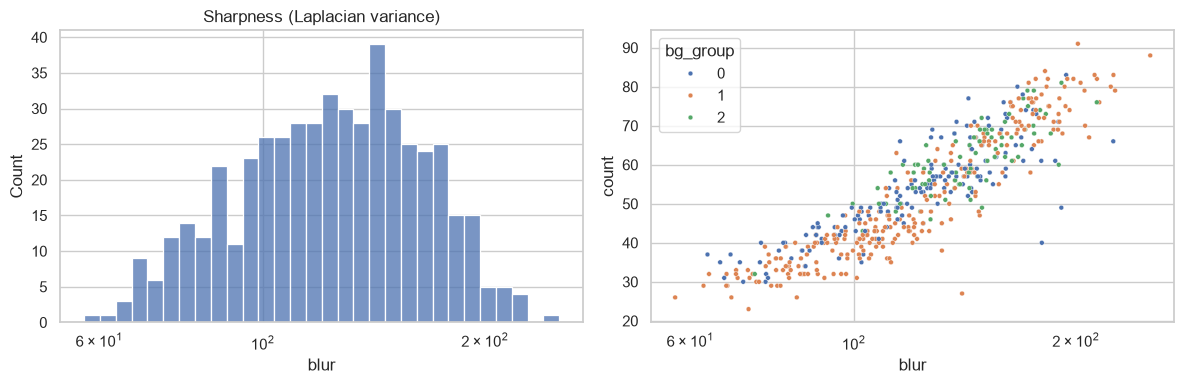

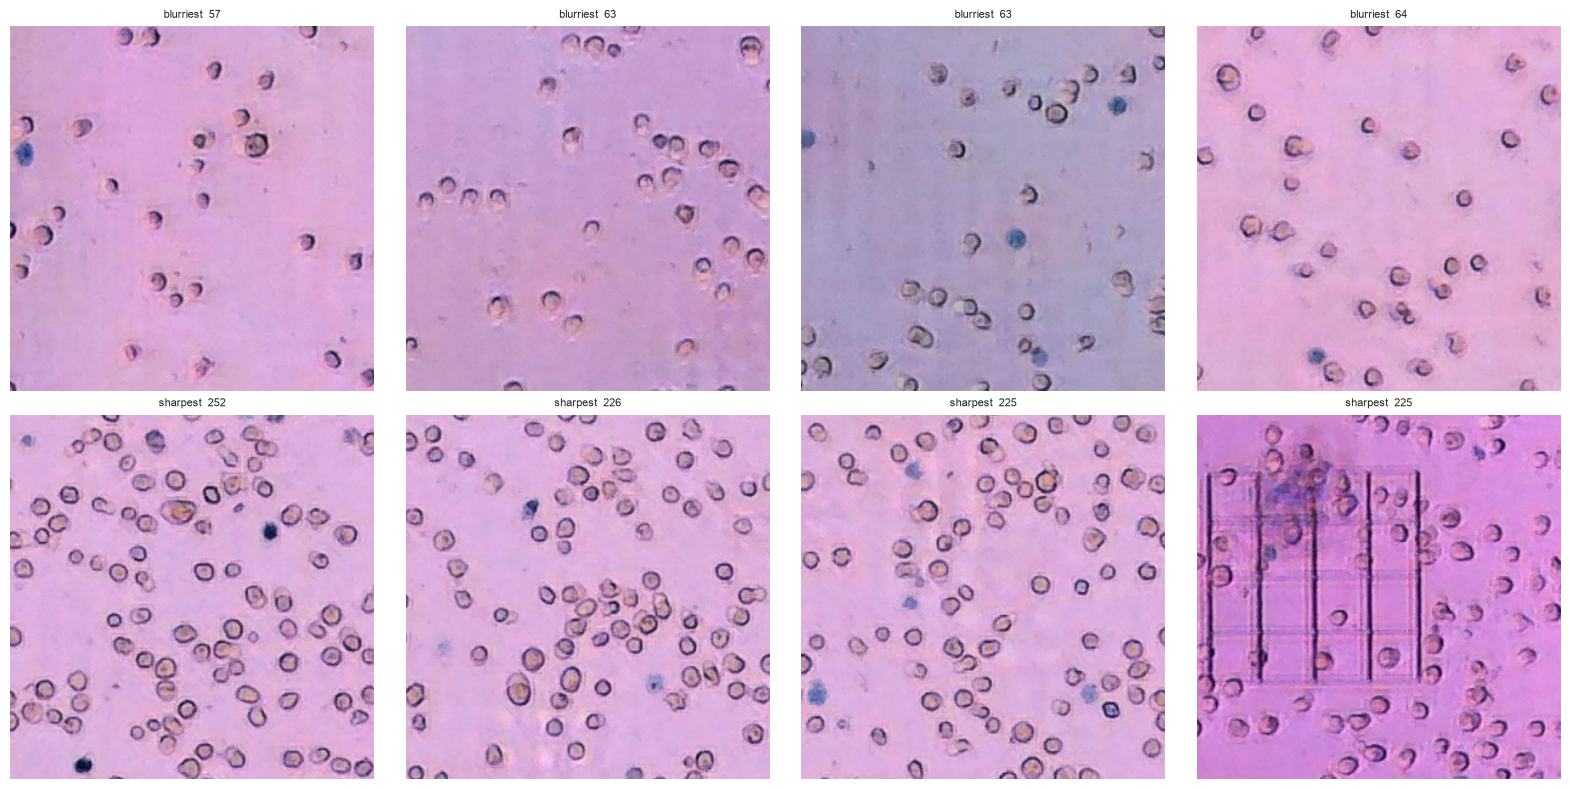

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(images, x="blur", log_scale=True, bins=30, ax=axes[0]); axes[0].set_title("Sharpness (Laplacian variance)")
sns.scatterplot(data=images, x="blur", y="count", hue="bg_group", palette="deep", s=12, ax=axes[1]); axes[1].set_xscale("log")
plt.tight_layout()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes[0], images.nsmallest(4, "blur").iterrows()):
    viz.show_image(row, ax=ax, title=f"blurriest  {row['blur']:.0f}")
for ax, (_, row) in zip(axes[1], images.nlargest(4, "blur").iterrows()):
    viz.show_image(row, ax=ax, title=f"sharpest  {row['blur']:.0f}")
plt.tight_layout()

## 8. Near-duplicates and leakage

Perceptual-hash pairs with Hamming distance ≤ 4. A pair whose two images sit in different splits is leakage.

In [16]:
pairs, dup_groups = eda.find_duplicates(stats, images, max_distance=4)
images["dup_group"] = images["uid"].map(dup_groups)
print(f"near-duplicate pairs: {len(pairs)}  (cross-split: {pairs['cross_split'].sum()})")
print(f"images in a duplicate group: {images['dup_group'].duplicated(keep=False).sum()}")
if len(pairs):
    display(pairs.groupby(["split_a", "split_b"]).size().rename("pairs").to_frame())
    viz.show_pairs(pairs.sort_values("distance"), images, n=4)

near-duplicate pairs: 0  (cross-split: 0)
images in a duplicate group: 0


## 9. Label outliers

In [17]:
W = boxes["uid"].map(images.set_index("uid")["width"])
H = boxes["uid"].map(images.set_index("uid")["height"])
boxes["at_border"] = (boxes["x"] <= 1) | (boxes["y"] <= 1) | (boxes["x"] + boxes["w"] >= W - 1) | (boxes["y"] + boxes["h"] >= H - 1)
q1, q3 = boxes["size"].quantile([0.25, 0.75]); iqr = q3 - q1
boxes["size_outlier"] = (boxes["size"] < q1 - 3 * iqr) | (boxes["size"] > q3 + 3 * iqr)
print("images with 0 cells       :", (images["count"] == 0).sum())
print("boxes touching the border :", f"{boxes['at_border'].mean():.1%}")
print("extreme-size boxes (3*IQR):", boxes["size_outlier"].sum())
print("images with extreme boxes :", boxes.loc[boxes["size_outlier"], "uid"].nunique())

images with 0 cells       : 0
boxes touching the border : 4.7%
extreme-size boxes (3*IQR): 29
images with extreme boxes : 27


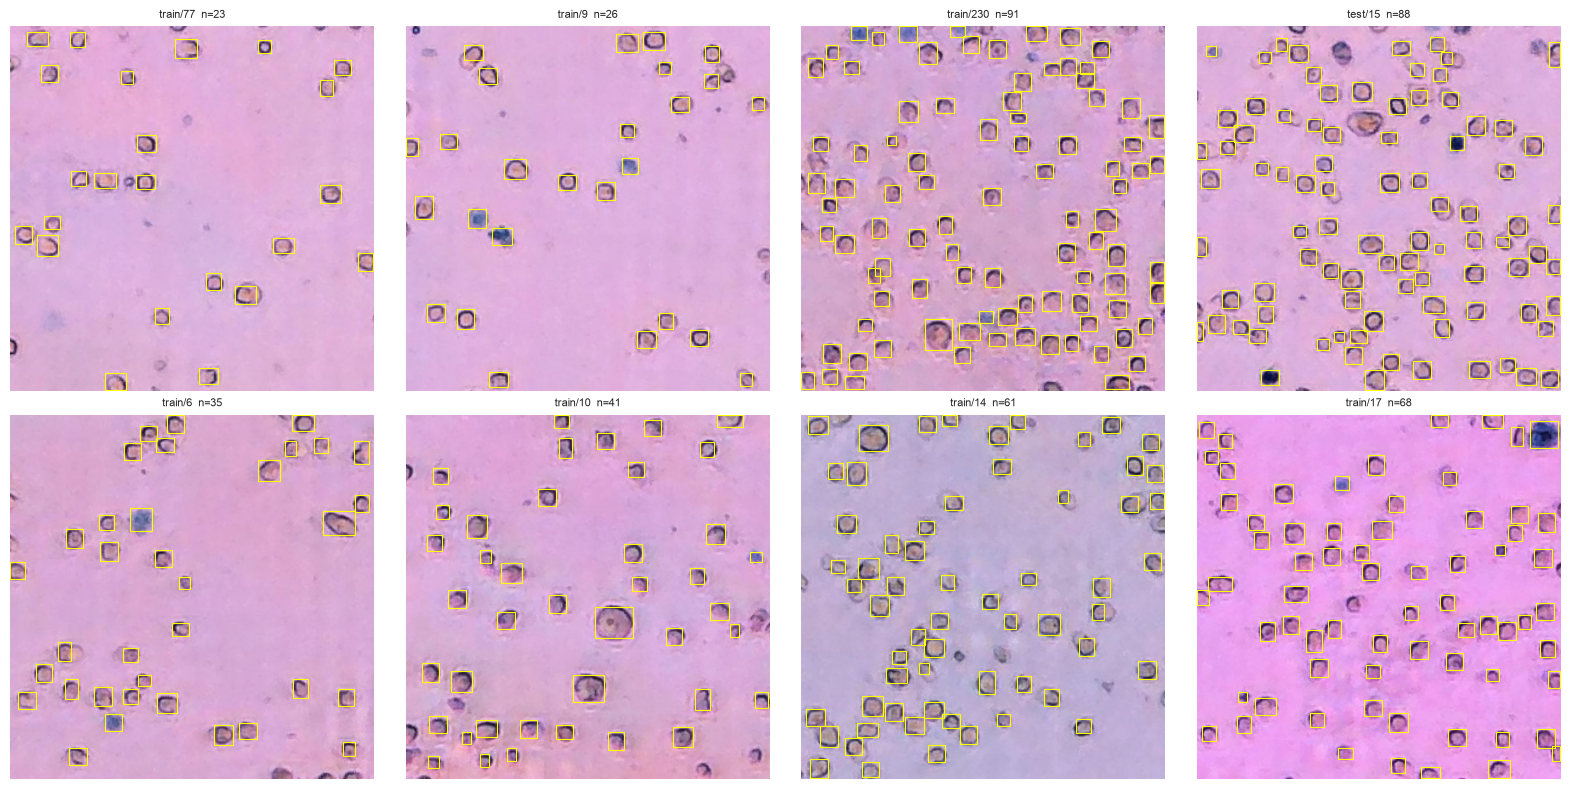

In [18]:
odd = images[images["uid"].isin(boxes.loc[boxes["size_outlier"], "uid"])].head(4)
extremes = pd.concat([images.nsmallest(2, "count"), images.nlargest(2, "count"), odd]).drop_duplicates("uid").head(8)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, extremes.iterrows()):
    viz.show_image(row, boxes, ax=ax)
for ax in axes.flat[len(extremes):]:
    ax.axis("off")
plt.tight_layout()

## 10. Proposed split

**Main split:** 70/15/15, stratified by source × count bin and grouped by near-duplicate group. Every source and density range appears in each split in the same proportions. It is saved to `splits/splits.csv`, which is committed so every collaborator uses the same images.

**Generalization check:** with only 5 sources, also report **leave-one-source-out** cross-validation (train on 4 sources, test on the 5th) using the `source` column in `splits/splits.csv`. This shows how much of a model's skill carries over to an unseen sample or well.

/Users/dingshandeng/anaconda3/envs/cellcount/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=20.
  warnings.warn(


new_split,test,train,valid,All
source,,,,
2022_12_7_1_A,16,70,14,100
2022_12_7_1_B,16,70,14,100
2022_12_7_2_A,15,70,15,100
2022_12_7_2_B,13,72,15,100
2022_12_7_3_A,15,69,16,100
All,75,351,74,500


new_split,test,train,valid,All
count_bin,,,,
"(-inf, 42.0]",21,98,20,139
"(42.0, 54.0]",18,86,20,124
"(54.0, 65.0]",17,82,16,115
"(65.0, inf]",19,85,18,122
All,75,351,74,500


saved /Users/dingshandeng/project/2-project_AInML/cell-image-counting/splits/splits.csv


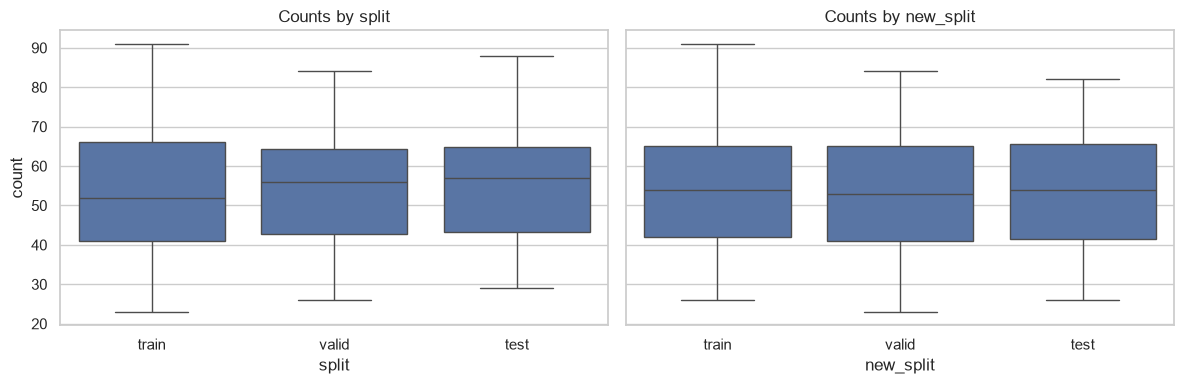

In [19]:
images["strata"] = images["source"].astype(str) + "|" + images["count_bin"].astype(str)
images["new_split"] = splits.make_splits(images, group_col="dup_group", stratify_col="strata", seed=42)
display(pd.crosstab(images["source"], images["new_split"], margins=True))
display(pd.crosstab(images["count_bin"], images["new_split"], margins=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col in zip(axes, ["split", "new_split"]):
    sns.boxplot(data=images, x=col, y="count", order=["train", "valid", "test"], ax=ax)
    ax.set_title(f"Counts by {col}")
plt.tight_layout()
# Saved inside the repo (not outputs/) so the split is committed and shared by everyone.
from cellcount.config import REPO_ROOT
(REPO_ROOT / "splits").mkdir(exist_ok=True)
out = splits.save_splits(images, REPO_ROOT / "splits" / "splits.csv")
print("saved", out)

## Findings → preprocessing decisions

_From the run on the fork's raw export (500 images). Update if the data changes._

### What the data is
- **500 unique images**, all 640×640 RGB, with 26,715 boxes in two classes: **Live** (25,691) and **Dead** (1,024, about 3.8%; the blue-stained cells, which suggests a trypan-blue viability assay).
- The public Roboflow version (about 1,200 images) is the same 500 images: the 350 training images are augmented 3× and everything is stretched to 640×640. **Do not use it.** The extra training images are copies, not new data.
- **Only 5 acquisition sources** (`2022_12_7_{1,2,3}_{A,B}`), each with 100 frames. Consecutive frames are different fields of view, not overlapping crops.
- **Counts:** 23–91 cells per image (median 54), with no empty images. **Count depends heavily on the source:** source means range from 37.5 to 71.1, with a within-source std of about 8.
- **Colour clusters mostly match the source.** For example, `1_A` is all in background group 0 and `3_A` is mostly group 2. A model could learn "background colour → count" instead of counting cells.
- **Cells are uniform:** about 28 px across (IQR 25–31 px), roughly square, with Live and Dead the same size.
- **Almost no overlap:** the median image has a max IoU of 0.006, and 0.1% of cells overlap another cell. **This dataset does not test the project's dense or overlapping-cell goal**; that needs the synthetic set or CoNIC (Phase 4).
- No near-duplicates by perceptual hash. Sharpness varies about 4× across images.

### 1. Inclusion and exclusion
- **Keep all 500 images.** None are empty, duplicated, or unreadable.
- **Label caveat:** faint or out-of-focus cells are often unlabeled, so the ground truth counts in-focus cells only. Classical baselines (threshold or watershed) will over-count unless they filter by focus or contrast. Keep this in mind when reading baseline errors.
- 27 images contain a box of extreme size (more than 3×IQR away from the median). The ones checked are real large cells or clumps, not errors, so keep them.
- 4.7% of boxes touch the image edge (cut-off cells). Decide on one rule (count them, which is what the labels currently do) and apply it to tiling later.

### 2. Transformations
- **No resizing needed:** every image is 640×640 and cells are about 28 px, so models can train at full resolution. Downscaling to 320 px would still leave cells about 14 px across.
- **Normalize colour:** per-channel mean/std (or ImageNet statistics for pretrained backbones). Use **colour jitter, hue shift, and stain-style augmentation** so the model can't use background colour to guess the source.
- **Geometric augmentation is safe:** flips and 90° rotations don't change the count. Mild Gaussian blur matches the real sharpness range.
- **Targets:** total count (for regression), boxes (for detection), or Gaussian density maps at the box centres (σ ≈ 4–7 px, about a quarter of the cell size). Live and Dead counts can be extra outputs.

### 3. Splits
- Roboflow's own split is **unbalanced across sources** (its test set has 5 images from `2_A` and 14 from `3_A`), so we replace it.
- **`splits/splits.csv`** (committed): 350/75/75, stratified by source × count bin. Each source contributes about 70/15/15.
- **Overfitting risk is high:** there are only 350 training images, and effectively 5 "domains". Use pretrained backbones, strong augmentation, and early stopping on the validation set.
- **Generalization:** also report **leave-one-source-out** cross-validation (5 folds, one per source). The gap between that and the random-split score measures how much a model depends on recognizing the source.